<a href="https://colab.research.google.com/github/emslaboratory/SYSC4415/blob/master/W2026/Assignments/A1/SYSC4415_W26_A1.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Required Setup for local Running if you are not using Google Colab

Install [Anaconda distribution] (https://docs.anaconda.com/anaconda/install/)

If you don't have Python on your computer, you can use the [Anaconda Python distribution](http://continuum.io/downloads) to install most of the Python packages you need. Anaconda provides a simple double-click installer for your convenience.

This notebook uses several Python packages that come standard with the Anaconda Python distribution. The primary libraries that we'll be using are:

* **NumPy**: Provides a fast numerical array structure and helper functions.
* **pandas**: Provides a DataFrame structure to store data in memory and work with it easily and efficiently.
* **scikit-learn/sklearn**: The essential Machine Learning package in Python.
* **matplotlib**: Basic plotting library in Python; most other Python plotting libraries are built on top of it.
* **Seaborn**: Advanced statistical plotting library.
* **waterqmark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.

To make sure you have all of the packages you need, install them with `conda`:

```
conda create -n SYSC4415_tutorials python=3.11
conda activate SYSC4415_tutorials

conda install jupyter
conda install numpy pandas scikit-learn matplotlib seaborn graphviz statsmodels
conda install -c conda-forge watermark

```

`conda` may ask you to update some of them if you don't have the most recent version. Allow it to do so.

## NOTE about Signature in Google Colab:

Use `!pip install watermark` in Google Colab if you have errors while signing your notebook. If you work locally and follow the instructions above in the correct order, it should be already installed.

## General Instructions:

Please print out values when asked using Python's print() function with f-strings where possible.

Submit your saved notebook with all the outputs to Brightspace, but make sure that it will produce correct outputs upon restarting and click "runtime" → "run all" with clean outputs. Ensure your notebook displays all answers when this is clicked.

## Your Submission MUST contain your signature at the bottom.


In [2]:
# Name: Andrew Roberts
# Student Number: 101268396

In [17]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
import graphviz
!pip install watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.0 MB/s eta 0:00:00


## Section 1: Gradients (4 marks)
Hint: use attached PDF if you get lost.

In [4]:
"""
Q1a (1 mark)
- Manually derive and calculate the gradient of the function: f(x,y,z) = e^(x²) + y^y + e^(xy) + zcos(x) at point (0,1, 1)
- Show each component of the gradient.

Print your answer using print() function showing all three partial derivatives.
"""

# YOUR ANSWER HERE
print("Partial derivative of x: 2xe^(x^2) + ye^(xy) - zsin(x), resulting in 1 with input values")
print("Partial derivative of y: y^y(ln(y) + 1) + xe^(xy), resulting in 1 with input values")
print("Partial derivative of z: cos(x), resulting in 1 with input values")

Partial derivative of x: 2xe^(x^2) + ye^(xy) - zsin(x), resulting in 1 with input values
Partial derivative of y: y^y(ln(y) + 1) + xe^(xy), resulting in 1 with input values
Partial derivative of z: cos(x), resulting in 1 with input values


In [5]:
"""
Q1b (1 mark)
For each component of the gradient calculated in Q1a:
- Explain what the value means geometrically
- Provide a conclusion about each term and gradient in general
"""

# YOUR ANSWER HERE
print("For each of the partial derivatives, the result of 1 means that if you move in the positive x, y, or z from point(0, 1, 1), the function increases at a rate of 1 unit per unit step in x, y, or z, respectively.")
print("Conclustions:\nThe gradient vector is f=(1, 1, 1) at point (0, 1, 1).")
print("All three components being equal and positive means the function increases equally in all three coordinate directions at this point.")
print("The magnitude f = sqrt(1^2 + 1^2 + 1^2) = sqrt(3) represents the rate of maximum increase.")
print("This vector points in the direction of the steepest ascent of the function.")
print("Moving in the direction opposite to the gradient (-1, -1, -1) would give the steepest decsent.")

For each of the partial derivatives, the result of 1 means that if you move in the positive x, y, or z from point(0, 1, 1), the function increases at a rate of 1 unit per unit step in x, y, or z, respectively.
Conclustions:
The gradient vector is f=(1, 1, 1) at point (0, 1, 1).
All three components being equal and positive means the function increases equally in all three coordinate directions at this point.
The magnitude f = sqrt(1^2 + 1^2 + 1^2) = sqrt(3) represents the rate of maximum increase.
This vector points in the direction of the steepest ascent of the function.
Moving in the direction opposite to the gradient (-1, -1, -1) would give the steepest decsent.


In [6]:
"""
Q1c (2 marks)
Write a Python function to verify your gradient calculation numerically:
1. Implement the function f(x,y,z)
2. Calculate numerical approximations of partial derivatives using small perturbations
3. Compare your analytical results from Q1a with numerical approximations
4. Report the result of function evaluation at the point (0,1,1)
"""

# YOUR ANSWER HERE
def f(x, y, z):
    return np.exp(x**2) + y**y + np.exp(x*y) + z*np.cos(x)

def gradient(x, y, z, h=1e-6):
    df_dx = (f(x+h, y, z) - f(x, y, z)) / h

    df_dy = (f(x, y+h, z) - f(x, y, z)) / h

    df_dz = (f(x, y, z+h) - f(x, y, z)) / h

    return df_dx, df_dy, df_dz

analytical = (1, 1, 1)

numerical = gradient(0, 1, 1)

print("Analytical gradient:", analytical)
print("Numerical gradient:", numerical)
print("Difference:", np.array(analytical) - np.array(numerical))

result = f(0, 1, 1)
print("f(0, 1, 1) =", result)

Analytical gradient: (1, 1, 1)
Numerical gradient: (np.float64(1.0000010002286785), np.float64(1.0000010002286785), np.float64(1.000000000139778))
Difference: [-1.00022868e-06 -1.00022868e-06 -1.39777967e-10]
f(0, 1, 1) = 4.0


## Section 2: Data Analysis (8 marks)

This section uses the Palmer Penguins dataset, which contains measurements from three penguin species.
The dataset includes physical measurements like bill length, bill depth, flipper length, and body mass. We are building a penguin classifier. First we need to assess out data.

In [7]:
"""
Q2a (1 mark)
✅ Load the Palmer Penguins dataset using Seaborn's load_dataset (provided)
- Show that it contains valid data
- Create variables for numerical features and labels
- Perform basic statistical analysis by printing the general statistics table as in Tutorials.
- Find missing values and drop records with missing values for any feature
- Save entries with missing values for "sex" in a separate variable, we'll use it later.
"""

# Load data
penguins = sb.load_dataset("penguins")

# YOUR ANSWER HERE
print(penguins.shape)
print(penguins)

numerical_features = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
labels = penguins[['species', 'island', 'sex']]
print("\nNumerical features:")
print(numerical_features)
print("\nLabels:")
print(labels)

print("\nGeneral Statistics Table:")
print(penguins.describe())

print("\nMissing values per column: \n", penguins.isnull().sum())
missing_sex = penguins[penguins['sex'].isnull()]
print(f"\nEntries with missing 'sex': {len(missing_sex)}")
print(missing_sex)

missing_values = penguins[penguins.isnull().any(axis=1)]
print("Missing values:\n", missing_values)
penguins_clean = penguins.dropna()
print(f"\nOriginal dataset size: {len(penguins)}")
print(f"Clean dataset size: {len(penguins_clean)}")
print("\nMissing values after cleaning:")
print(penguins_clean.isnull().sum())

(344, 7)
    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen            39.1           18.7              181.0   
1    Adelie  Torgersen            39.5           17.4              186.0   
2    Adelie  Torgersen            40.3           18.0              195.0   
3    Adelie  Torgersen             NaN            NaN                NaN   
4    Adelie  Torgersen            36.7           19.3              193.0   
..      ...        ...             ...            ...                ...   
339  Gentoo     Biscoe             NaN            NaN                NaN   
340  Gentoo     Biscoe            46.8           14.3              215.0   
341  Gentoo     Biscoe            50.4           15.7              222.0   
342  Gentoo     Biscoe            45.2           14.8              212.0   
343  Gentoo     Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
0         3750.0    Male  
1         3800.0  Female


Creating scatterplot matrix...


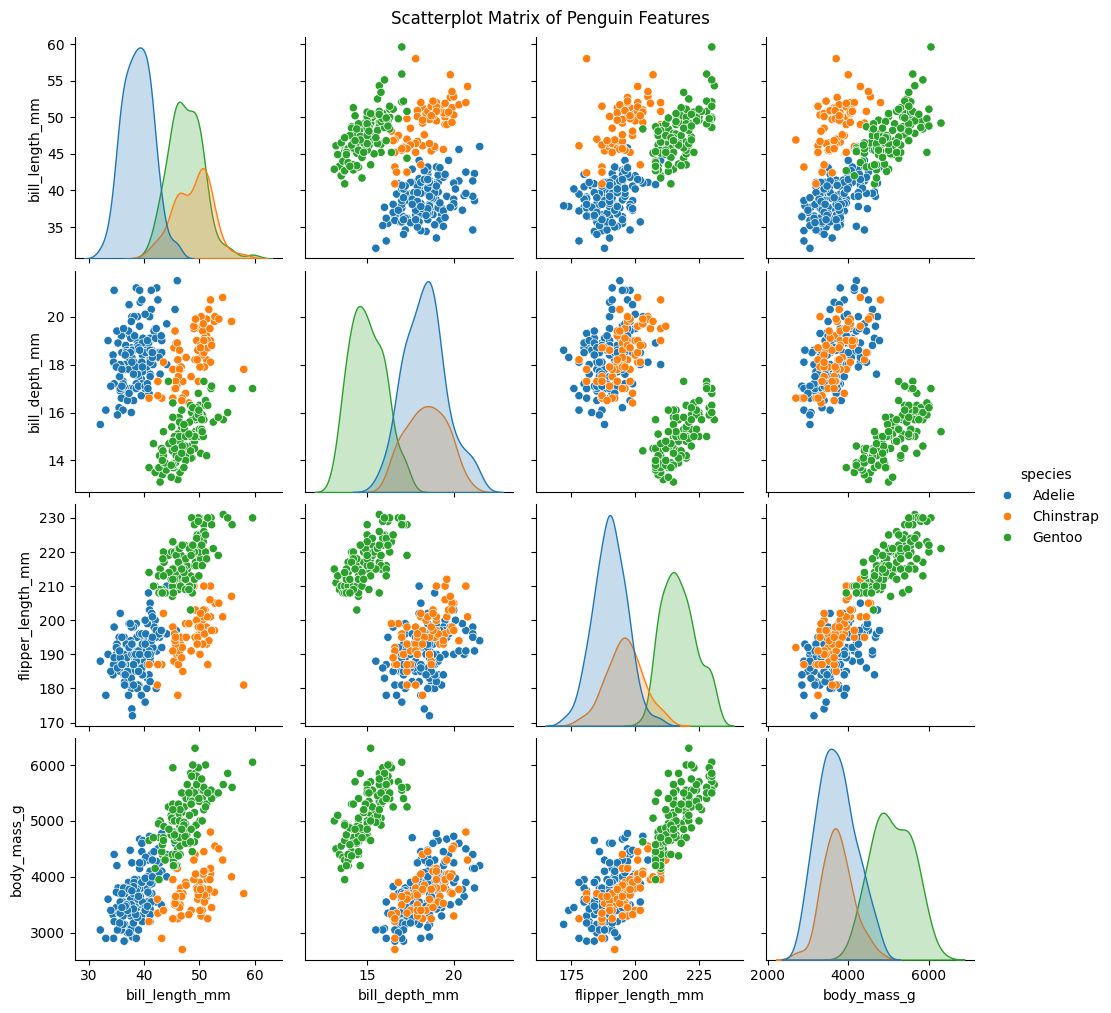

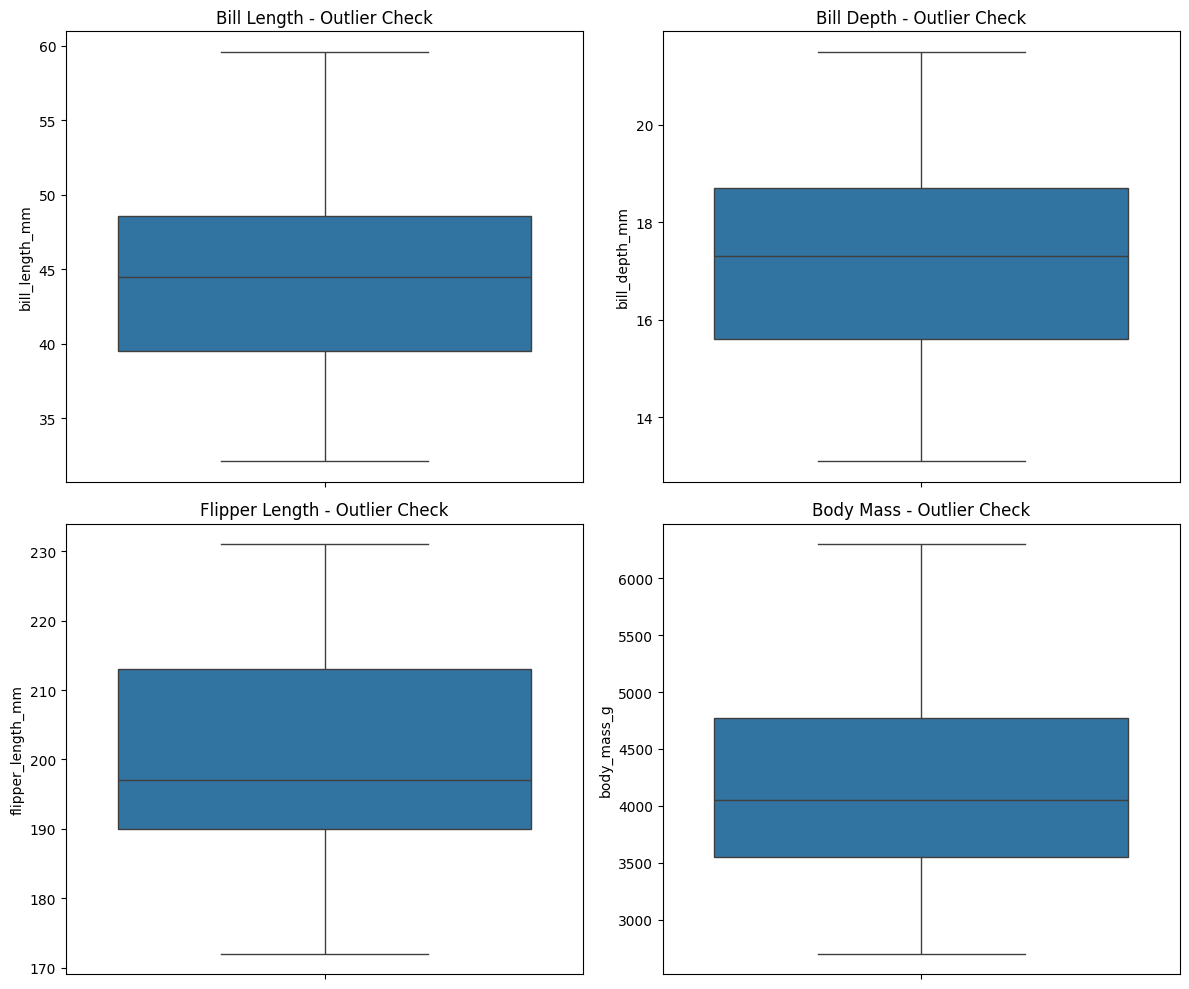

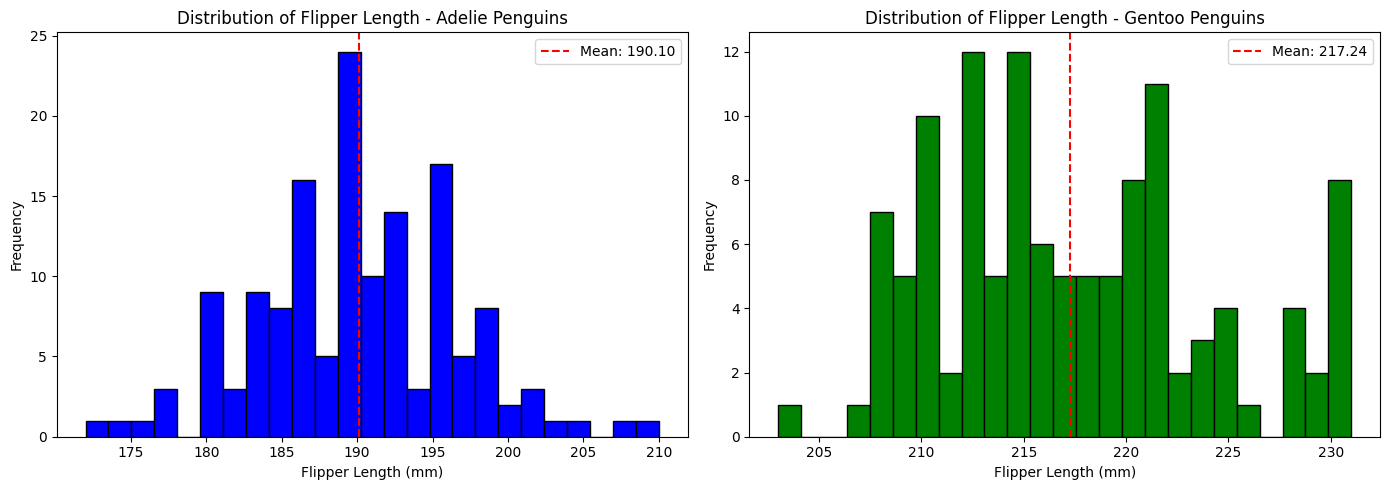

In [8]:
"""
Q2b (2 marks)
Create visualizations showing:
- Create scatterplot matrix for visual assessment of data
- Identify one feature with outliers and show distribution values for two classes (2 histograms).
"""

# YOUR ANSWER HERE
# Scatterplot
print("\nCreating scatterplot matrix...")
sb.pairplot(penguins_clean, hue='species')
plt.suptitle("Scatterplot Matrix of Penguin Features", y=1.01)
plt.show()

# Identify feature with outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sb.boxplot(data=penguins_clean, y='bill_length_mm', ax=axes[0,0])
axes[0,0].set_title('Bill Length - Outlier Check')

sb.boxplot(data=penguins_clean, y='bill_depth_mm', ax=axes[0,1])
axes[0,1].set_title('Bill Depth - Outlier Check')

sb.boxplot(data=penguins_clean, y='flipper_length_mm', ax=axes[1,0])
axes[1,0].set_title('Flipper Length - Outlier Check')

sb.boxplot(data=penguins_clean, y='body_mass_g', ax=axes[1,1])
axes[1,1].set_title('Body Mass - Outlier Check')

plt.tight_layout()
plt.show()

# choosing flipper_length_mm
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram 1: Adelie species
adelie_data = penguins_clean[penguins_clean['species'] == 'Adelie']['flipper_length_mm']
axes[0].hist(adelie_data, bins=25, color='blue', edgecolor='black')
axes[0].set_xlabel('Flipper Length (mm)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Flipper Length - Adelie Penguins')
axes[0].axvline(adelie_data.mean(), color='red', linestyle='--', label=f'Mean: {adelie_data.mean():.2f}')
axes[0].legend()

# Histogram 2: Gentoo species
gentoo_data = penguins_clean[penguins_clean['species'] == 'Gentoo']['flipper_length_mm']
axes[1].hist(gentoo_data, bins=25, color='green', edgecolor='black')
axes[1].set_xlabel('Flipper Length (mm)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Flipper Length - Gentoo Penguins')
axes[1].axvline(gentoo_data.mean(), color='red', linestyle='--', label=f'Mean: {gentoo_data.mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()


Class Distribution Analysis:

Class Counts:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Class Proportions (%):
species
Adelie       43.843844
Gentoo       35.735736
Chinstrap    20.420420
Name: proportion, dtype: float64


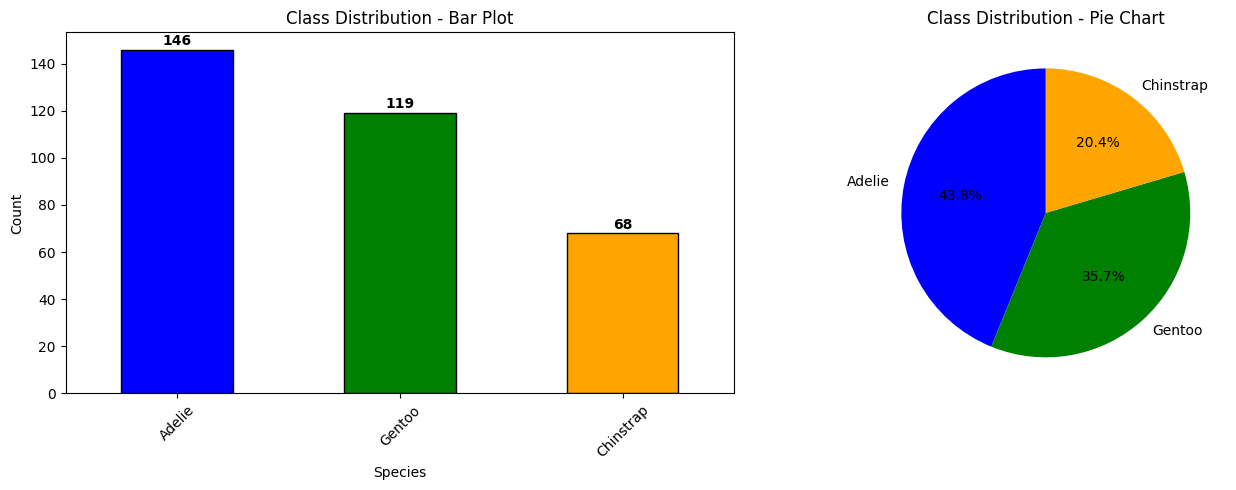


Class Imbalance Analysis:
Largest class: Adelie with 146 samples
Smallest class: Chinstrap with 68 samples
Imbalance ratio: 2.15

Moderate to significant class imbalance
Implications for model training:
Model may be biased toward the majority class
Use precision, recall, and F1-score instead of relying only on accuracy
Apply stratified splitting to maintain class proportions
Consider class weighting or resampling


In [9]:
"""
Q2c (1 mark)
Analyze class distribution and discuss implications for model training:
- Calculate and visualize class proportions
- Identify any class imbalance
"""

# YOUR ANSWER HERE
# Calculate class proportions
print("\nClass Distribution Analysis:")

# Count of each species
class_counts = penguins_clean['species'].value_counts()
print("\nClass Counts:")
print(class_counts)

# Proportions/Percentages
class_proportions = penguins_clean['species'].value_counts(normalize=True) * 100
print("\nClass Proportions (%):")
print(class_proportions)

# Visualize class proportions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts.plot(kind='bar', ax=axes[0], color=['blue', 'green', 'orange'], edgecolor='black')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution - Bar Plot')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

for i, v in enumerate(class_counts):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=['blue', 'green', 'orange'], startangle=90)
axes[1].set_title('Class Distribution - Pie Chart')

plt.tight_layout()
plt.show()

# Identify class imbalance
print("\nClass Imbalance Analysis:")

max_class = class_counts.max()
min_class = class_counts.min()
imbalance_ratio = max_class / min_class

print(f"Largest class: {class_counts.idxmax()} with {max_class} samples")
print(f"Smallest class: {class_counts.idxmin()} with {min_class} samples")
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 2:
    print("\nModerate to significant class imbalance")
    print("Implications for model training:")
    print("Model may be biased toward the majority class")
    print("Use precision, recall, and F1-score instead of relying only on accuracy")
    print("Apply stratified splitting to maintain class proportions")
    print("Consider class weighting or resampling")
else:
    print("\nClasses are relatively balanced.")
    print("Standard training approaches should work well.")

## Section 3: Model Development (8 marks)
After polishing thedata, let's make our classification model.

In [10]:
"""
Q3a (2 marks)
Preprocess the data:
- Use the clean dataset from Q2a (with missing values removed)
- Split into training (80%) and test (20%) sets using random_state=42
- Print first 5 rows of training data with their species labels
- Print shapes of both datasets
- Show number of samples per species in each split
"""

# YOUR ANSWER HERE
# Separate features and target
X = penguins_clean[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = penguins_clean['species']

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n1. First 5 rows of training data with species labels:")
# Combine features and labels for display
train_display = X_train.head().copy()
train_display['species'] = y_train.head().values
print(train_display)

print("\n2. Dataset shapes:")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")

print("\n3. Number of samples per species in each split:")
print("\nTraining set distribution:")
print(y_train.value_counts().sort_index())
print(f"Total training samples: {len(y_train)}")

print("\nTest set distribution:")
print(y_test.value_counts().sort_index())
print(f"Total test samples: {len(y_test)}")


1. First 5 rows of training data with species labels:
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g    species
268            44.9           13.3              213.0       5100.0     Gentoo
205            50.7           19.7              203.0       4050.0  Chinstrap
337            48.8           16.2              222.0       6000.0     Gentoo
123            41.4           18.5              202.0       3875.0     Adelie
38             37.6           19.3              181.0       3300.0     Adelie

2. Dataset shapes:
Training set shape: (266, 4)
Test set shape: (67, 4)
Training labels shape: (266,)
Test labels shape: (67,)

3. Number of samples per species in each split:

Training set distribution:
species
Adelie       117
Chinstrap     54
Gentoo        95
Name: count, dtype: int64
Total training samples: 266

Test set distribution:
species
Adelie       29
Chinstrap    14
Gentoo       24
Name: count, dtype: int64
Total test samples: 67



Training Accuracy: 1.0000 (100.00%)
Test Accuracy: 0.9552 (95.52%)

10-Fold Cross-Validation Results:
CV Scores: [1.         0.96296296 0.96296296 0.96296296 1.         0.96296296
 0.96153846 1.         0.96153846 0.92307692]
Mean CV Score: 0.9698 (96.98%)
Standard Deviation: 0.0229
Min Score: 0.9231
Max Score: 1.0000


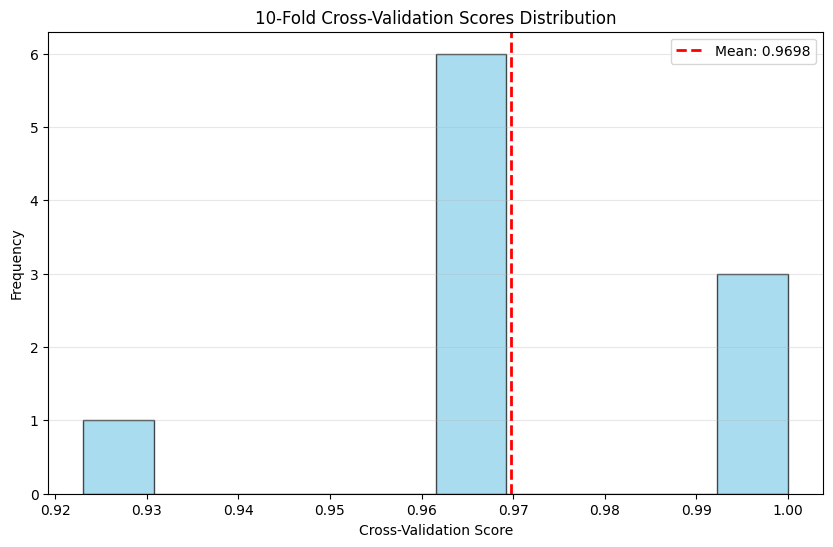


Histogram Interpretation:
The histogram shows:
- Distribution of model performance across 10 different train/validation splits
- The spread indicates model stability/variance
- Mean CV score (0.9698) vs Test accuracy (0.9552)
- Low standard deviation suggests the model is STABLE across different data splits
- Small gap between training accuracy and CV score suggests good generalization


In [11]:
"""
Q3b (3 marks)
Train and evaluate a Decision Tree:
1. Create a Decision Tree with default parameters (random_state=42)
2. Evaluate the model:
   - Fit on training data (numerical features only)
   - Print training and test accuracy score for this tree
   - Perform 10-fold cross-validation
   - Print mean and std of cross-validation scores and build cv_scores histogram.
   - What does the histogram show?
"""

from sklearn.model_selection import cross_val_score

# YOUR ANSWER HERE
# Create a Decision Tree with default parameters
dt_model = DecisionTreeClassifier(random_state=42)

# Fit on training data
dt_model.fit(X_train, y_train)

# Print training and test accuracy scores
train_accuracy = dt_model.score(X_train, y_train)
test_accuracy = dt_model.score(X_test, y_test)

print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Perform 10-fold cross-validation
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=10)

# Print mean and std of cross-validation scores
print(f"\n10-Fold Cross-Validation Results:")
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"Min Score: {cv_scores.min():.4f}")
print(f"Max Score: {cv_scores.max():.4f}")

# Build cv_scores histogram
plt.figure(figsize=(10, 6))
plt.hist(cv_scores, bins=10, edgecolor='black', color='skyblue', alpha=0.7)
plt.axvline(cv_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Cross-Validation Score')
plt.ylabel('Frequency')
plt.title('10-Fold Cross-Validation Scores Distribution')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Histogram Interpretation
print("\nHistogram Interpretation:")
print("The histogram shows:")
print(f"- Distribution of model performance across 10 different train/validation splits")
print(f"- The spread indicates model stability/variance")
print(f"- Mean CV score ({cv_scores.mean():.4f}) vs Test accuracy ({test_accuracy:.4f})")

if cv_scores.std() < 0.05:
    print("- Low standard deviation suggests the model is STABLE across different data splits")
else:
    print("- High standard deviation suggests the model performance VARIES across splits")

if train_accuracy - cv_scores.mean() > 0.1:
    print("- Large gap between training accuracy and CV score suggests OVERFITTING")
elif train_accuracy - cv_scores.mean() < 0.05:
    print("- Small gap between training accuracy and CV score suggests good generalization")


Performing Grid Search...
Fitting 5 folds for each of 256 candidates, totalling 1280 fits

Best Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}

Best Cross-Validation Score: 0.9774
Best Test Score: 0.9552


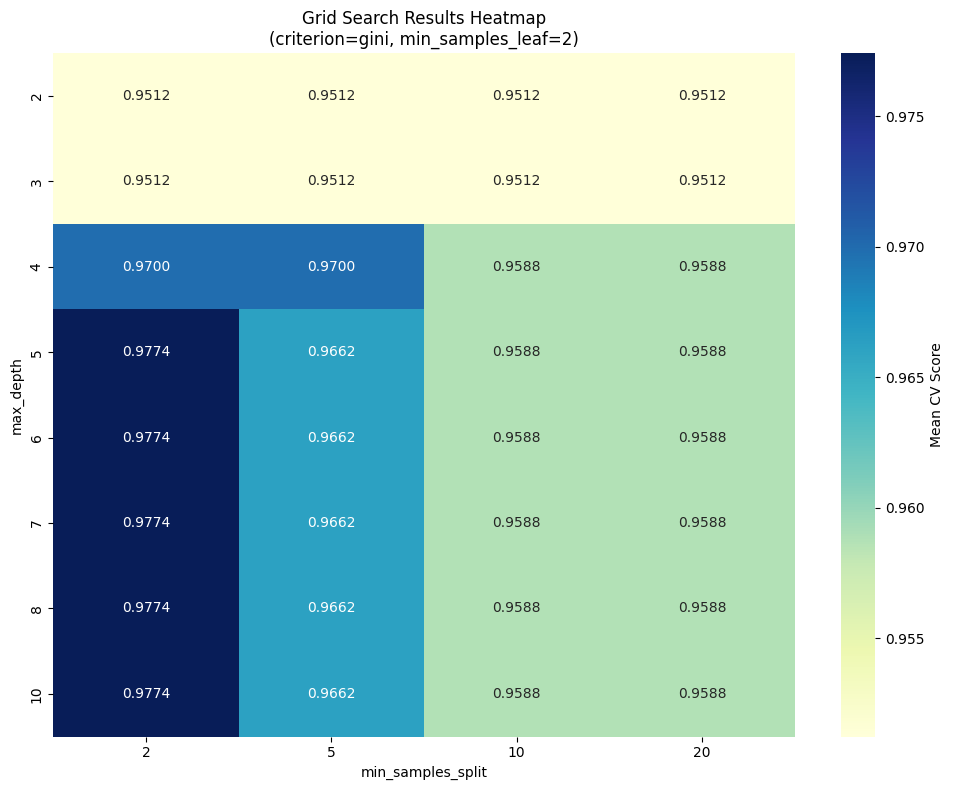


Visualizing Best Tree Structure (max_depth=2 for clarity)...


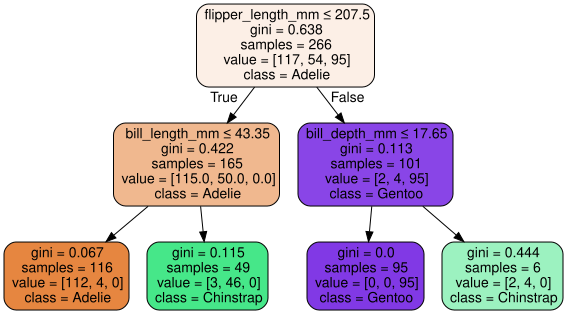

In [12]:
"""
Q3c (3 marks)
Analyze the best model from grid search:
- Initialize parameter_grid, cross_validation using StratifiedKFold
- Identify the best parameters for the tree and show the grid heatmap (don't forget labels)
- Plot the best tree structure using graphviz, use max_depth=2 (for better display)

Note: when using export_graphviz set out_file=None and use display(graph) function call, where
graph is your variable instantiated with Source(dot_data)
Export_graphviz Documentation: https://scikit-learn.org/1.5/modules/generated/sklearn.tree.export_graphviz.html
"""
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

import graphviz
from sklearn.tree import export_graphviz
from graphviz import Source

# YOUR ANSWER HERE
# Initialize parameter grid
parameter_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# Initialize StratifiedKFold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=parameter_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
print("\nPerforming Grid Search...")
grid_search.fit(X_train, y_train)

# Identify best parameters
print("\nBest Parameters:")

print(grid_search.best_params_)
print(f"\nBest Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"Best Test Score: {grid_search.score(X_test, y_test):.4f}")

# Create heatmap for grid search results
# Focus on two main parameters for visualization
results_df = pd.DataFrame(grid_search.cv_results_)

# Create pivot table for heatmap (max_depth vs min_samples_split)
# Filter for best criterion and min_samples_leaf
best_criterion = grid_search.best_params_['criterion']
best_min_leaf = grid_search.best_params_['min_samples_leaf']

filtered_results = results_df[
    (results_df['param_criterion'] == best_criterion) &
    (results_df['param_min_samples_leaf'] == best_min_leaf)
]

pivot_table = filtered_results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_min_samples_split'
)

plt.figure(figsize=(10, 8))
sb.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': 'Mean CV Score'})
plt.title(f'Grid Search Results Heatmap\n(criterion={best_criterion}, min_samples_leaf={best_min_leaf})')
plt.xlabel('min_samples_split')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

# Plot the best tree structure with max_depth=2 for display
print("\nVisualizing Best Tree Structure (max_depth=2 for clarity)...")

# Create a new tree with best parameters but max_depth=2 for visualization
best_tree_viz = DecisionTreeClassifier(
    max_depth=2,
    min_samples_split=grid_search.best_params_['min_samples_split'],
    min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
    criterion=grid_search.best_params_['criterion'],
    random_state=42
)

best_tree_viz.fit(X_train, y_train)

# Export tree to graphviz
dot_data = export_graphviz(
    best_tree_viz,
    out_file=None,
    feature_names=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
    class_names=['Adelie', 'Chinstrap', 'Gentoo'],
    filled=True,
    rounded=True,
    special_characters=True
)

# Create graph and display
graph = Source(dot_data)
display(graph)


## Section 4: Missing_Sex Prediction (4 marks)
In this part of the assignment, we are building a model to infer the missing values from the original dataset to fix the broken records.


In [13]:
"""
Q4a (2 marks)
Prepare data for sex prediction:
- Use the clean dataset (no missing values) from Section 2
- Convert species to numeric values.

Note: Unlike the example in the tutorial, we will use a more straightforward method, LabelEncoder().

For this task, you just need to instantiate it, use the fit_transform method on the "species" column,
and reassign or add the column.
See documentation for details:
https://scikit-learn.org/dev/modules/generated/sklearn.preprocessing.LabelEncoder.html

- Create new feature/label split using "sex" as target
- Scale features using StandardScaler().fit_transform(features) as in Tutorial
See documentation: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

- Split data into training (80%) and test (20%) sets
- Train these classifiers:
  * Logistic Regression (solver='lbfgs')
  * Decision Tree (max_depth=3)
  * KNN (n_neighbors=5)
  * SVM (kernel="linear", C=0.025)
- Compare models using (Providing values for each would be enough):
  * Training and test accuracy
  * 10-fold cross-validation scores


"""

# Prepare features including species as numeric
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# YOUR ANSWER HERE
# Use clean dataset and convert species to numeric
# Create a copy to avoid modifying original
data_q4 = penguins_clean.copy()

# Convert species to numeric using LabelEncoder
le = LabelEncoder()
data_q4['species_numeric'] = le.fit_transform(data_q4['species'])

print("\nSpecies encoding:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# Create new feature/label split using "sex" as target
X_sex = data_q4[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species_numeric']]
y_sex = data_q4['sex']

# Scale features using StandardScaler
scaler = StandardScaler()
X_sex_scaled = scaler.fit_transform(X_sex)

# Split data into training (80%) and test (20%) sets
X_train_sex, X_test_sex, y_train_sex, y_test_sex = train_test_split(
    X_sex_scaled, y_sex, test_size=0.2, random_state=42, stratify=y_sex
)

print(f"\nTraining set size: {X_train_sex.shape}")
print(f"Test set size: {X_test_sex.shape}")

# Train classifiers
models = {
    'Logistic Regression': LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='linear', C=0.025, random_state=42)
}

# Compare models
results = []

print("\nModel Comparison:")
print("-" * 80)

for name, model in models.items():
    # Train the model
    model.fit(X_train_sex, y_train_sex)

    # Calculate accuracies
    train_acc = model.score(X_train_sex, y_train_sex)
    test_acc = model.score(X_test_sex, y_test_sex)

    # 10-fold cross-validation
    cv_scores = cross_val_score(model, X_train_sex, y_train_sex, cv=10)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    # Store results
    results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'CV Mean': cv_mean,
        'CV Std': cv_std
    })

    print(f"\n{name}:")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  CV Mean: {cv_mean:.4f}")
    print(f"  CV Std: {cv_std:.4f}")

# Create summary table
results_df = pd.DataFrame(results)
print("\nSummary Table:")
print(results_df.to_string(index=False))


Species encoding:
{'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}

Training set size: (266, 5)
Test set size: (67, 5)

Model Comparison:
--------------------------------------------------------------------------------

Logistic Regression:
  Training Accuracy: 0.9135
  Test Accuracy: 0.9104
  CV Mean: 0.9020
  CV Std: 0.0429

Decision Tree:
  Training Accuracy: 0.9398
  Test Accuracy: 0.8358
  CV Mean: 0.9095
  CV Std: 0.0491

KNN:
  Training Accuracy: 0.9511
  Test Accuracy: 0.9254
  CV Mean: 0.9211
  CV Std: 0.0389

SVM:
  Training Accuracy: 0.9023
  Test Accuracy: 0.9104
  CV Mean: 0.8984
  CV Std: 0.0449

Summary Table:
              Model  Train Accuracy  Test Accuracy  CV Mean   CV Std
Logistic Regression        0.913534       0.910448 0.901994 0.042919
      Decision Tree        0.939850       0.835821 0.909544 0.049087
                KNN        0.951128       0.925373 0.921083 0.038861
                SVM        0.902256       0.910448 0.898433 0.0449

In [15]:
"""
Q4b (2 marks)
Use best model to predict missing sex:
- Make sure to create new variable for subset to work with and copy your variable with missing records into it,
using new_var = your_variable.copy().
- Print records with missing sex values from section 2.
- Remove records that have missing values other than sex using dropna: df.dropna(subset=['column_name'],inplace=True).
- Scale features using StandardScaler().fit_transform(features) as in Q3
- Create new features/labels variables for the new dataset.

- Select best classifier based on test performance from Q4a

- For each record in missing_sex dataset, using best_model.predict(features) and best_model.predict_proba(features)
- Add missing values to the clean dataset and make sure there are no missing values.
"""

# YOUR ANSWER HERE
# Create new variable for subset to work with
missing_sex_subset = missing_sex.copy()

# Print records with missing sex values
print("\nRecords with missing sex values:")
print(missing_sex_subset)
print(f"\nTotal records with missing sex: {len(missing_sex_subset)}")

# Remove records that have missing values other than sex
missing_sex_subset.dropna(subset=['bill_length_mm', 'bill_depth_mm',
                                   'flipper_length_mm', 'body_mass_g',
                                   'species'], inplace=True)

print(f"\nRecords after removing other missing values: {len(missing_sex_subset)}")

# Convert species to numeric for missing_sex_subset
missing_sex_subset['species_numeric'] = le.transform(missing_sex_subset['species'])

# Create features for the missing sex dataset
X_missing = missing_sex_subset[['bill_length_mm', 'bill_depth_mm',
                                 'flipper_length_mm', 'body_mass_g',
                                 'species_numeric']]

# Scale features using the same scaler from Q4a
X_missing_scaled = scaler.transform(X_missing)

print("\nScaled features for missing sex records:")
print(f"Shape: {X_missing_scaled.shape}")

# Select best classifier based on test performance from Q4a
best_model_name = results_df.loc[results_df['Test Accuracy'].idxmax(), 'Model']
best_model = models[best_model_name]

print(f"\nBest model selected: {best_model_name}")
print(f"Test Accuracy: {results_df.loc[results_df['Test Accuracy'].idxmax(), 'Test Accuracy']:.4f}")

# Predict missing sex values
predictions = best_model.predict(X_missing_scaled)
probabilities = best_model.predict_proba(X_missing_scaled)

print("\nPredictions for missing sex values:")
for i, (idx, row) in enumerate(missing_sex_subset.iterrows()):
    print(f"Index {idx}: Predicted = {predictions[i]}, "
          f"Probability = {probabilities[i]}")

# Add predictions to the missing_sex_subset
missing_sex_subset['sex'] = predictions

print("\nUpdated records with predicted sex:")
print(missing_sex_subset[['species', 'island', 'bill_length_mm', 'bill_depth_mm',
                          'flipper_length_mm', 'body_mass_g', 'sex']])

# Add missing values back to the clean dataset
# Create a complete dataset
penguins_complete = penguins_clean.copy()

# Concatenate the clean dataset with the missing_sex_subset
# Drop the species_numeric column from missing_sex_subset first
missing_sex_to_add = missing_sex_subset.drop(columns=['species_numeric'])

# Combine the datasets
penguins_complete = pd.concat([penguins_complete, missing_sex_to_add], ignore_index=False)

# Sort by index to maintain order
penguins_complete = penguins_complete.sort_index()

# Verify no missing values
print("\nMissing values in complete dataset:")
print(penguins_complete.isnull().sum())

print(f"\nComplete dataset size: {len(penguins_complete)}")


Records with missing sex values:
    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
3    Adelie  Torgersen             NaN            NaN                NaN   
8    Adelie  Torgersen            34.1           18.1              193.0   
9    Adelie  Torgersen            42.0           20.2              190.0   
10   Adelie  Torgersen            37.8           17.1              186.0   
11   Adelie  Torgersen            37.8           17.3              180.0   
47   Adelie      Dream            37.5           18.9              179.0   
246  Gentoo     Biscoe            44.5           14.3              216.0   
286  Gentoo     Biscoe            46.2           14.4              214.0   
324  Gentoo     Biscoe            47.3           13.8              216.0   
336  Gentoo     Biscoe            44.5           15.7              217.0   
339  Gentoo     Biscoe             NaN            NaN                NaN   

     body_mass_g  sex  
3            NaN  NaN  
8    

#### Congratulations! What you just did is called **model-based multiple imputation**. It is one of the methods used to treat missing data.

## Signature:
Don't forget to insert your name and student number and execute.

In [19]:
# Provide your Signarure:
%load_ext watermark
%watermark -a 'Andrew Roberts, 101268396' -nmv --packages numpy,pandas,sklearn,matplotlib,seaborn,graphviz

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Author: Andrew Roberts, 101268396

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

numpy     : 2.0.2
pandas    : 2.2.2
sklearn   : 1.6.1
matplotlib: 3.10.0
seaborn   : 0.13.2
graphviz  : 0.21

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.105+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 2
Architecture: 64bit

